# 05 - Rendering: frames on the terrain

The maps of the earlier notebooks were points and polygons. This one puts the *pictures* on the ground: each frame projected onto the DEM as an orthophoto (a GeoTIFF a GIS can drape), the frames of a stretch stitched into an orthomosaic, and - the reason this project exists - many frames integrated into one airborne light-field (ALFS) image, in which the canopy blurs away and the ground beneath stays sharp.

All of it runs through alfspy - whichever backend is installed, ModernGL or PyTorch - behind `bambi.render`, and the results are arrays with DEM-local bounds; `bambi.io.geotiff` turns them into files.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
from _setup import ensure_environment, get_flight, get_dem, find
ensure_environment()

import json
import numpy as np
import cv2
import matplotlib.pyplot as plt


bambi-detection ready. data dir: C:\D\Projects\bambi_detection\.test-data


## Setup: flight 146, a few thermal frames

The processed video of the `base` download is thermal|RGB side by side; frames are the left half. Poses and DEM as before; the DEM is loaded twice - as a mesh for ray casting and as *render data* (mesh + texture) for the renderer.

In [2]:
from bambi.io.dem import read_dem_mesh, read_render_data
from bambi.io.poses import read_poses, to_local_poses
from bambi.io.corrections import read_corrections, corrections_for_frames
from bambi.util.render_context import make_render_context, render_backend

flight = get_flight("146", version="base")
glb = get_dem("146")
dem = read_dem_mesh(glb)
mesh_data, texture_data = read_render_data(glb)
pf = read_poses(find(flight, "*_matched_poses.json")[0])
poses = to_local_poses(pf, epsg=dem.origin.epsg, origin=dem.origin)
t_corr, r_corr = corrections_for_frames(read_corrections(flight / "146_correction.json"), len(poses))
EPSG = dem.origin.epsg
ORIGIN = np.array([dem.origin.easting, dem.origin.northing])
W = H = 1024
FOVY = 50.0

def thermal_frame(idx):
    cap = cv2.VideoCapture(str(flight / "146_matched_processed.mp4"))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, img = cap.read(); cap.release()
    return img[:, :W] if ok else None                                # BGR, as OpenCV reads it

ctx = make_render_context()
print("render backend:", render_backend())

flight 146 (base) cached at C:\D\Projects\bambi_detection\.test-data\base\146
flight 146 (base) cached at C:\D\Projects\bambi_detection\.test-data\base\146


render backend: torch


## 1 - One frame as an orthophoto

`frame_orthophoto` is the plugin's per-frame GeoTIFF recipe in one call: cast the frame's valid-area polygon onto the terrain for the extent, size the raster from metres per pixel, project the frame orthographically into it, erode the antialiased rim. Out come the image, a validity mask and DEM-local bounds - and `write_frame_geotiff` turns each into the plugin's `geotiffs_t/<frame>.tiff`: an LZW GeoTIFF in the world CRS, the invalid rim as nodata, a `.tfw` world file beside it. Note the origin shift: everything is computed DEM-local and moved to UTM only when the file is written.

frame 1900: 444x445 px, 44.4 x 44.4 m, 83% valid


frame 2400: 483x462 px, 48.3 x 46.2 m, 81% valid


frame 2900: 486x475 px, 48.5 x 47.5 m, 81% valid


frame 3400: 478x469 px, 47.8 x 46.9 m, 80% valid


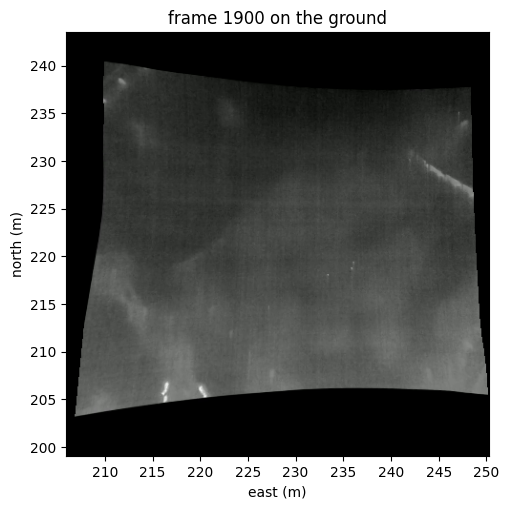

In [3]:
from bambi.render.ortho import frame_orthophoto
from bambi.render.masks import default_mask_polygon
from bambi.io.geotiff import write_frame_geotiff, read_geotiff

frames = [1900, 2400, 2900, 3400]
out_dir = flight / "geotiffs_demo"; out_dir.mkdir(exist_ok=True)
tiffs = []
for f in frames:
    img, valid, bounds = frame_orthophoto(ctx, mesh_data, texture_data, dem.mesh, thermal_frame(f),
                                          poses.positions[f], poses.rotations[f], FOVY, W, H,
                                          polygon=default_mask_polygon(W, H), ground_resolution=0.1,
                                          translation_correction=t_corr[f], rotation_correction=r_corr[f])
    world = (bounds[0] + ORIGIN[0], bounds[1] + ORIGIN[1], bounds[2] + ORIGIN[0], bounds[3] + ORIGIN[1])
    tiffs.append(write_frame_geotiff(out_dir / f"{f:08d}.tiff", img[:, :, ::-1], valid, world, EPSG))
    print(f"frame {f}: {img.shape[1]}x{img.shape[0]} px, {bounds[2]-bounds[0]:.1f} x {bounds[3]-bounds[1]:.1f} m, {valid.mean():.0%} valid")

shown, b, _, _ = read_geotiff(tiffs[0])
plt.figure(figsize=(5.5, 5.5)); plt.imshow(shown, extent=(b[0]-ORIGIN[0], b[2]-ORIGIN[0], b[1]-ORIGIN[1], b[3]-ORIGIN[1]))
plt.title(f"frame {frames[0]} on the ground"); plt.xlabel("east (m)"); plt.ylabel("north (m)"); plt.show()

## 2 - Frames into an orthomosaic

`merge_average` does what the plugin's orthomosaic step does: one pass to fix the output grid, one to sum valid pixels and count contributors, then the average. `count_overlaps` is the plugin's coverage map from the same files (notebook 04 built the same map from footprints, without renders).

orthomosaic 685x1578 px; 0.54 ha covered, max overlap 2


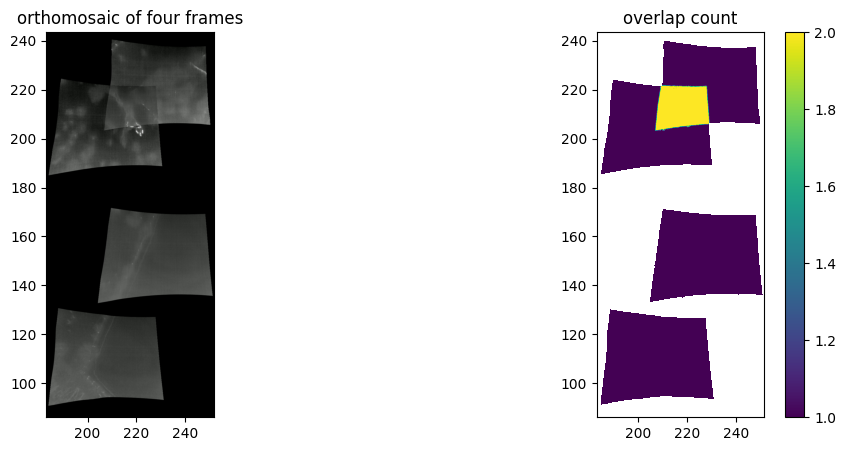

In [4]:
from bambi.io.geotiff import merge_average, count_overlaps

mosaic = merge_average(tiffs, out_dir / "orthomosaic.tif")
img, b, _, _ = read_geotiff(mosaic)
count, cb = count_overlaps(tiffs)
print(f"orthomosaic {img.shape[1]}x{img.shape[0]} px; {(count>0).sum()/1e4*0.01:.2f} ha covered, max overlap {count.max()}")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ext = (b[0]-ORIGIN[0], b[2]-ORIGIN[0], b[1]-ORIGIN[1], b[3]-ORIGIN[1])
ax[0].imshow(img, extent=ext); ax[0].set_title("orthomosaic of four frames")
im = ax[1].imshow(np.where(count > 0, count, np.nan), extent=ext, cmap="viridis"); ax[1].set_title("overlap count")
plt.colorbar(im, ax=ax[1]); plt.show()

## 3 - The light-field integral

Take a window of consecutive frames around one moment, make a shot of each, and render their *integral* over the union of their footprints: alfspy adds every projected frame and normalises by how many saw each pixel. Where the frames agree (the ground) the picture stays sharp; where they disagree (canopy seen from different angles) it averages out. `make_shots` builds the shots lazily, so hundreds cost little until they are drawn.

21 frames -> integral 484x528 px over 48 x 53 m


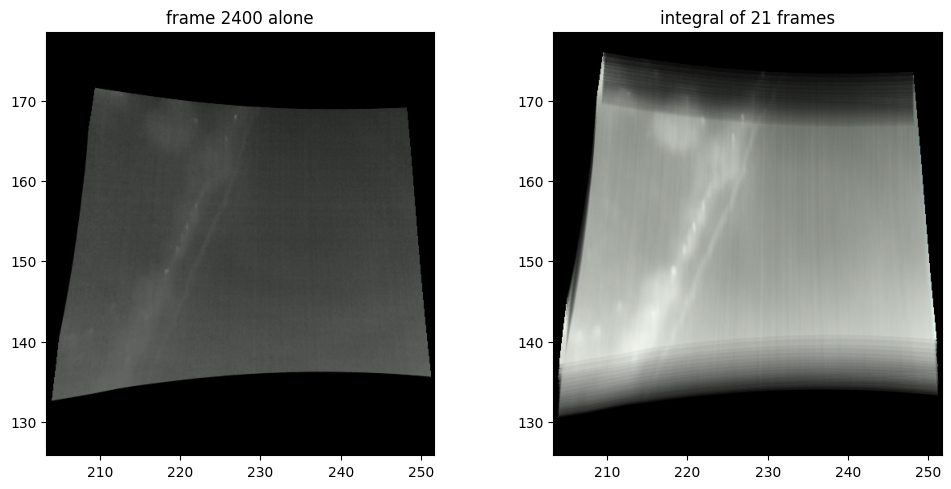

In [5]:
from bambi.render.ortho import make_shots, render_orthographic, render_size
from bambi.render.masks import polygon_bounds
from bambi.geo.georef import footprint
from bambi.geo.camera import cameras_from_poses

centre = 2400
window = np.arange(centre - 30, centre + 31, 3)                    # 21 frames, every 3rd
images = [thermal_frame(f) for f in window]
shots = make_shots(ctx, images, poses, FOVY, W / H, t_corr, r_corr, indices=window, lazy=True)
fps = [footprint(cam, W, H, dem.mesh) for cam in cameras_from_poses(poses, FOVY, W / H, t_corr, r_corr, indices=window)]
bounds = polygon_bounds(np.vstack(fps))
size = render_size(bounds[2] - bounds[0], bounds[3] - bounds[1], ground_resolution=0.1, max_dim=4000)
integral = render_orthographic(ctx, mesh_data, texture_data, shots, bounds, size, integral=True, release_shots=True)
single = render_orthographic(ctx, mesh_data, texture_data,
                             make_shots(ctx, [thermal_frame(centre)], poses, FOVY, W / H, t_corr, r_corr, indices=[centre], lazy=False)[0],
                             bounds, size)
print(f"{len(window)} frames -> integral {size[0]}x{size[1]} px over {bounds[2]-bounds[0]:.0f} x {bounds[3]-bounds[1]:.0f} m")
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
ext = (bounds[0], bounds[2], bounds[1], bounds[3])
ax[0].imshow(single[:, :, [2, 1, 0]], extent=ext); ax[0].set_title(f"frame {centre} alone")
ax[1].imshow(integral[:, :, [2, 1, 0]], extent=ext); ax[1].set_title(f"integral of {len(window)} frames")
plt.show()

### The integral as a GeoTIFF

A light-field image goes to disk differently from an orthophoto. Its alpha channel is *information* - how much of the extent the shots covered, normalised - so `write_geotiff` keeps it as a fourth band (a GIS shows it as transparency) instead of turning it into nodata, and adds overview pyramids and a `.prj` beside the `.tfw`. This is the plugin's `alfs_t/alfs.tif`. For big extents `render_integral_tiled` cuts the raster into tiles - `tiles` / `tile_camera`, exactly as the plugin does - renders each from only the shots whose footprint touches it, and assembles the whole; memory stays bounded however large the survey.

alfs.tif: 484x528 px, 48 x 53 m, sidecars ['alfs.prj', 'alfs.tfw', 'alfs.tif']
bands 4 ('Red', 'Green', 'Blue', 'Alpha'), crs EPSG:32633, 0.10 m/px, overviews [2, 4, 8, 16]
pixel (0,0) is at UTM (466285.78, 5165763.85)
alpha kept: (528, 484, 4) coverage 84%


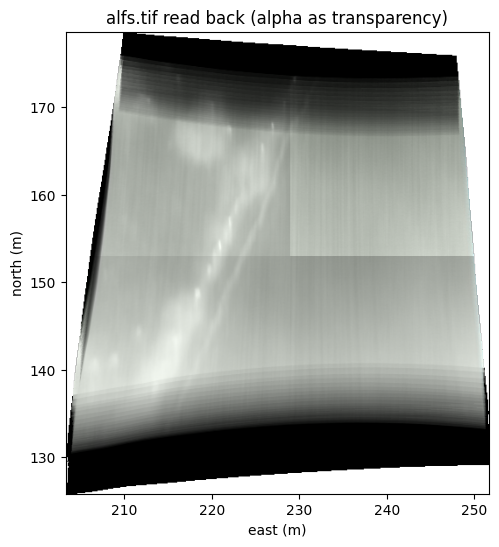

In [6]:
from bambi.render.ortho import render_integral_tiled
from bambi.io.geotiff import write_geotiff

# same window, rendered in 256 px tiles (a small tile size only to show the mechanism), then cropped
shots = make_shots(ctx, images, poses, FOVY, W / H, t_corr, r_corr, indices=window, lazy=True)
alfs, alfs_bounds = render_integral_tiled(ctx, mesh_data, texture_data, shots, bounds, size, max_tile=256,
                                          shot_footprints=fps, crop=True)
world = (alfs_bounds[0] + ORIGIN[0], alfs_bounds[1] + ORIGIN[1], alfs_bounds[2] + ORIGIN[0], alfs_bounds[3] + ORIGIN[1])
alfs_dir = flight / "alfs_demo"; alfs_dir.mkdir(exist_ok=True)
tif = write_geotiff(alfs_dir / "alfs.tif", alfs[:, :, [2, 1, 0, 3]], world, EPSG)     # BGR(A) -> RGB(A)
print(f"{tif.name}: {alfs.shape[1]}x{alfs.shape[0]} px, {alfs_bounds[2]-alfs_bounds[0]:.0f} x {alfs_bounds[3]-alfs_bounds[1]:.0f} m,"
      f" sidecars {[q.name for q in alfs_dir.iterdir()]}")

import rasterio
with rasterio.open(tif) as src:
    print(f"bands {src.count} {src.descriptions}, crs EPSG:{src.crs.to_epsg()}, {src.res[0]:.2f} m/px, overviews {src.overviews(1)}")
    x0, y0 = src.xy(0, 0)
    print(f"pixel (0,0) is at UTM ({x0:.2f}, {y0:.2f})")
back, b, _, _ = read_geotiff(tif)
print("alpha kept:", back.shape, "coverage", f"{(back[:, :, 3] > 0).mean():.0%}")
plt.figure(figsize=(6, 6)); plt.imshow(back, extent=(b[0]-ORIGIN[0], b[2]-ORIGIN[0], b[1]-ORIGIN[1], b[3]-ORIGIN[1]))
plt.title("alfs.tif read back (alpha as transparency)"); plt.xlabel("east (m)"); plt.ylabel("north (m)"); plt.show()

Two writers, then, for the two products - `write_frame_geotiff` (orthophoto: nodata rim, what an orthomosaic wants) and `write_geotiff` (light-field integral: alpha band, overviews) - and one `read_geotiff` for both. Both files open in QGIS as they are.

On this open enclosure the integral mostly *denoises* the thermal image; over forest it is what makes animals under the canopy visible at all.

## 4 - Render and ray cast agree - at any tilt

A render is only useful if it lands where the geo-referencing says. On the synthetic scene of `02_georeference`, a frame with a bright marker at a known pixel is rendered from a 45-degree view; the marker must appear where `pixels_to_world` puts that pixel. Both use the same pose convention (`quaternion_from_drone_pose`), so they do - which the older `'zyx'` spelling of the shot (`convention="zyx"`, kept for reproducing the plugin's current renders) does not guarantee once the camera tilts.

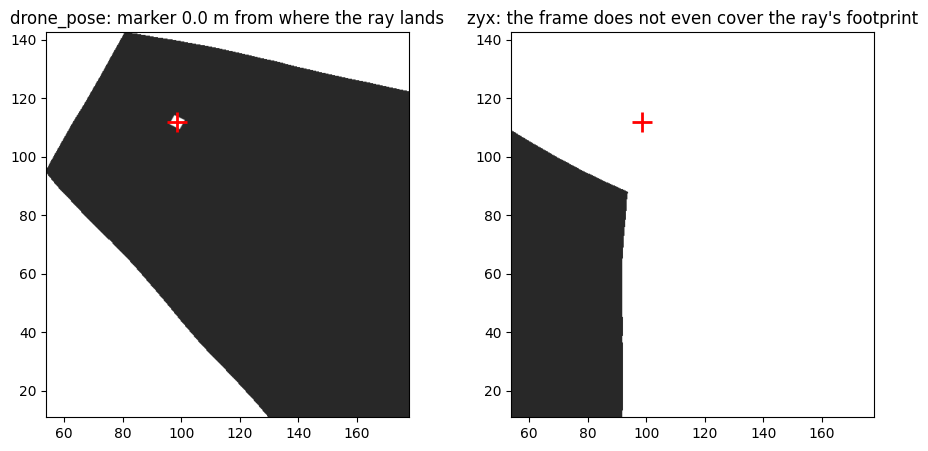

In [7]:
from bambi.testing.synthetic import make_scene
from bambi.io.dem import render_data_from_arrays
from bambi.geo import camera as cam, georef
from bambi.render.ortho import make_shot

scene = make_scene(tilts_deg=(45.0,), headings_deg=(120.0,), frame_size=(256, 256), fovy=50.0)
smesh_data, stexture = render_data_from_arrays(scene.vertices, scene.faces)
pos, rot = scene.poses.positions[0], scene.poses.rotations[0]
px, py = 96, 150
frame = np.full((256, 256, 3), 40, np.uint8); frame[py-6:py+6, px-6:px+6] = 255
camera = cam.camera_from_pose(pos, rot, 50.0)
truth = georef.pixels_to_world([px, py], camera, 256, 256, scene.mesh)[0]
sb = polygon_bounds(georef.footprint(camera, 256, 256, scene.mesh, samples_per_edge=4))
ssize = render_size(sb[2]-sb[0], sb[3]-sb[1], 0.25)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, conv in zip(ax, ("drone_pose", "zyx")):
    shot = make_shot(ctx, frame, pos, rot, 50.0, 1.0, lazy=False, convention=conv)
    r = render_orthographic(ctx, smesh_data, stexture, shot, sb, ssize)
    rows, cols = np.nonzero(r[:, :, :3].min(axis=2) > 200)
    a.imshow(r, extent=(sb[0], sb[2], sb[1], sb[3])); a.plot(truth[0], truth[1], "r+", ms=14, mew=2)
    if len(rows):
        cx = sb[0] + (cols.mean() + 0.5) * (sb[2]-sb[0]) / ssize[0]; cy = sb[3] - (rows.mean() + 0.5) * (sb[3]-sb[1]) / ssize[1]
        a.set_title(f"{conv}: marker {np.hypot(cx-truth[0], cy-truth[1]):.1f} m from where the ray lands")
    else:
        a.set_title(f"{conv}: the frame does not even cover the ray's footprint")
plt.show()

## Where this goes next

That is the whole engine: frames and poses (01), geo-referencing (02), tracking (03), survey analytics (04) and rendering (05), each on arrays, each proven against the QGIS plugin's output where an oracle exists (`tests/test_parity_*.py`). The plugin becomes the GUI over these calls next.